# E-value:10e-5, Identity=30%

This notebook reveals what transporter genes the pipeline identify, and how the reactions these genes facilitate, differ and correspond with iML1515.

In [91]:
import json
import pandas as pd
import ast
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
import re
from collections import defaultdict

In [92]:
e_val = "10e-5"
e_val_latex = "$10^{-5}$"
identity = "30"

In [93]:
with open("../iML1515.json", "r") as f:
    iml1515 = json.load(f)
gene_uniprot_map = {g["id"]: g.get("annotation", {}).get("uniprot", ["Unknown"]) for g in iml1515["genes"]}

In [94]:
e_coli = pd.read_csv(f"../outp/{e_val}_{identity}_e_coli_K12_MG1655_transporters_reactions.tsv", sep="\t")
# Only keeping the QUID entry with the lowest E-val, as others are homologous and orthologous hits
e_coli = e_coli.loc[e_coli.groupby("QUID")["Evalue"].idxmin()].reset_index(drop=True)
e_coli_uids = set(e_coli["QUID"])

In [95]:
chebi_to_name = {}

for reaction_list in e_coli["Reaction"]:
    reaction_list = ast.literal_eval(reaction_list)

    for name, chebi in reaction_list:
        if chebi not in chebi_to_name and chebi != "no_reaction_identified":
            chebi_to_name[chebi] = name

In [96]:
model = pd.read_csv("../iML1515_transport_rxs.tsv", sep="\t")
model_transport_uids = set(model["UIDs"].str.split(", ").explode())
model_transport_uids.remove("Unknown")

Interesting finding! Need to look into the reactions of those 952 cases.
I also need to assess the reactions in the common area.

In [97]:
only_model_uids = model_transport_uids - e_coli_uids
only_e_coli_uids = e_coli_uids - model_transport_uids

Here I roughly assess what kind of reactions are tied to the genes only found in the BLAST, and not in the model. I found that of those 952, 562 of those genes had no_reaction_identified. The remaining 390 genes had 1 or more reactions identified.

In [98]:
only_e_coli_reaction_df = e_coli[e_coli["QUID"].isin(only_e_coli_uids)]

In [99]:
all_uids_model = {uid
    for uid_list in gene_uniprot_map.values()
    for uid in uid_list
    if uid != "Unknown"
}

Here is a Venn of all the transporters identified from the BLAST, compared to all the genes in iML1515, including the subset of the reactions it has classified as transporters.

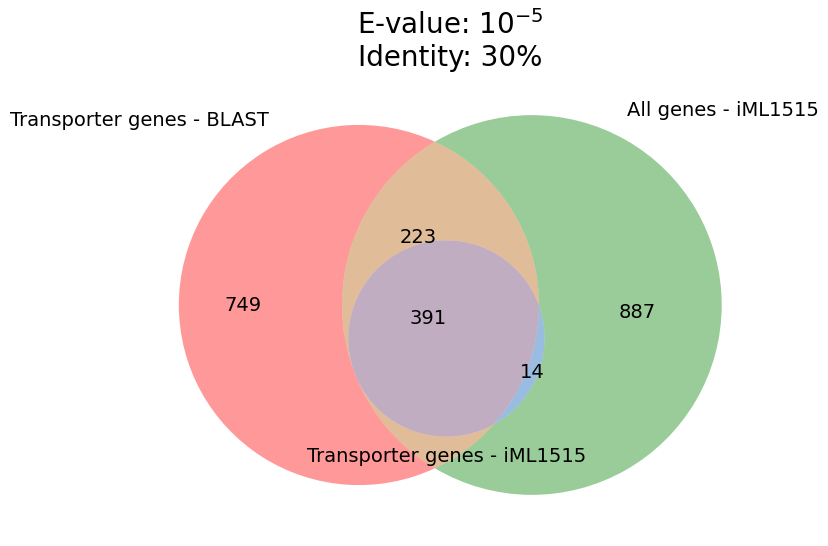

In [100]:
set1 = set(e_coli_uids)
set2 = set(all_uids_model)
set3 = set(model_transport_uids)
plt.figure(figsize=(10, 6))
out = venn3([set1, set2, set3],
      set_labels=("Transporter genes - BLAST", "All genes - iML1515", "Transporter genes - iML1515"))

for t in out.set_labels:
    t.set_fontsize(14)
if out.subset_labels is not None:
    for label in out.subset_labels:
        if label is not None:
            label.set_fontsize(14)

plt.title(f"E-value: {e_val_latex}\nIdentity: {identity}%", fontsize=20)
plt.savefig(f"../figs/transport_genes_tdb_iML1515_{e_val}_{identity}.pdf")
plt.show()

Here are the common transport genes between the BLAST and the iML1515-classified transporters

In [101]:
common_genes = set1 & set3
print(f"Genes common to BLASTp results and iML1515 transporter genes (n={len(common_genes)}):")
common_genes

Genes common to BLASTp results and iML1515 transporter genes (n=391):


{'P00550',
 'P02916',
 'P02920',
 'P02921',
 'P02924',
 'P02925',
 'P02929',
 'P02930',
 'P02931',
 'P02932',
 'P02943',
 'P03819',
 'P03959',
 'P03960',
 'P03961',
 'P04816',
 'P04983',
 'P05706',
 'P05825',
 'P06129',
 'P06609',
 'P06611',
 'P06971',
 'P06972',
 'P06996',
 'P07109',
 'P07117',
 'P07654',
 'P07821',
 'P07822',
 'P08194',
 'P08722',
 'P08839',
 'P09323',
 'P09551',
 'P09833',
 'P0A6J3',
 'P0A712',
 'P0A742',
 'P0A769',
 'P0A830',
 'P0A8H3',
 'P0A910',
 'P0A927',
 'P0A9S7',
 'P0A9X1',
 'P0AA04',
 'P0AA47',
 'P0AA67',
 'P0AA76',
 'P0AA78',
 'P0AA80',
 'P0AA82',
 'P0AAD2',
 'P0AAD4',
 'P0AAD6',
 'P0AAD8',
 'P0AAE0',
 'P0AAE2',
 'P0AAE5',
 'P0AAE8',
 'P0AAF1',
 'P0AAF3',
 'P0AAF6',
 'P0AAG0',
 'P0AAG3',
 'P0AAG8',
 'P0AAH0',
 'P0AAH4',
 'P0AAI1',
 'P0AAJ1',
 'P0AAT4',
 'P0AB93',
 'P0ABB8',
 'P0ABC9',
 'P0ABD1',
 'P0ABI4',
 'P0ABL8',
 'P0ABM1',
 'P0ABM5',
 'P0ABN5',
 'P0ABN9',
 'P0ABP3',
 'P0ABT8',
 'P0ABU7',
 'P0ABV2',
 'P0AC23',
 'P0AC26',
 'P0AC94',
 'P0AC96',
 'P0AC98',

Now, I want to look into the different reactions. This is done by comparing the set of substrates used in the reaction. It lacks precision, as iML1515 provides several CHEBIs for the same metabolite. As a temporary solution for this master, all the CHEBIs from the BLAST is here converted to a BiGG id (BID). Several CHEBIs map to the same BID. And the metabolite IDs in the model all map to one BID each. So this is a nice go-around, without using CHEBIs.\
First obtaining the ones from the BLAST.

In [102]:
c2b_df = pd.read_csv("../../../ChEBI/chebi2bigg.tsv", sep="\t")
c2b = {row["CHEBI"].upper().replace("CHEBI:", "CHEBI:"): row["BIGG"] for _, row in c2b_df.iterrows()}

temp_set_bigg = set()

for reaction_list in e_coli["Reaction"]:
    reaction_list = ast.literal_eval(reaction_list)
    
    for _, chebi_str in reaction_list:
        if chebi_str != "no_reaction_identified":

            matches = re.findall(r'CHEBI:\d+', chebi_str)
            if not matches:
                continue
            
            bigg_ids = {c2b.get(chebi.upper()) for chebi in matches}
            bigg_ids.discard(None)
            
            if bigg_ids:
                temp_set_bigg.add(frozenset(bigg_ids))

reactions_bigg_e_coli = [sorted(list(s)) for s in temp_set_bigg]
print(f"{len(reactions_bigg_e_coli)} different substrate sets, and by that reactions, are identified from BLAST")


350 different substrate sets, and by that reactions, are identified from BLAST


Then the substrates from the transport reactions in the model. The complete reactions from the whole model, and not just the transport reactions, would also be handy to compare, but this might be a too computationally comprehensive task, as the permutations of different CHEBIs for the same substrate, often are many, and obtaining all the permutations is both unsatisfactory and highly unefficient computationally.\
So here is the more usable BIDs, that are user-friendly, cross-reference-wise.

In [103]:
reactions_bigg_model_init = model["Substrates (BiGG)"]
parsed_sets = [ast.literal_eval(s) for s in reactions_bigg_model_init if pd.notnull(s)]
unique_model_sets = set(frozenset(s) for s in parsed_sets)
reactions_bigg_model = [sorted(list(s)) for s in unique_model_sets]
print(f"{len(reactions_bigg_model)} different substrate sets, and by that reactions, are identified in iML1515")

713 different substrate sets, and by that reactions, are identified in iML1515


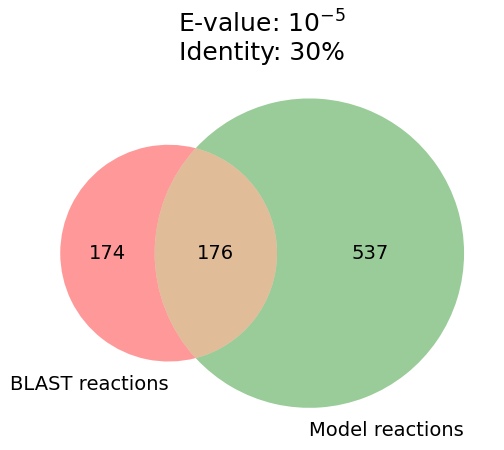

In [104]:
set_e_coli_bigg = set(frozenset(r) for r in reactions_bigg_e_coli)
set_model_bigg = set(frozenset(r) for r in reactions_bigg_model)

plt.figure(figsize=(6, 6))
out = venn2([set_e_coli_bigg, set_model_bigg], set_labels=("BLAST reactions", "Model reactions"))

for t in out.set_labels:
    t.set_fontsize(14)
for t in out.subset_labels:
    t.set_fontsize(14)

plt.title(f"E-value: {e_val_latex}\nIdentity: {identity}%", fontsize=18)
plt.savefig(f"../figs/reactions_tdb_iML1515_{e_val}_{identity}.pdf")
plt.show()

Now, it is desireable to identify the reactions only facilitated by the model. Identify which genes are responsible for these, and see what reactions the BLASTed genes say that these facilitate. Do they compare? Are they close? Is the BLAST more specific?

This looks into the whole TDB, to see if these IDs are found there.

In [105]:
model["Substrates (BiGG) frozen"] = model["Substrates (BiGG)"].apply(
    lambda x: frozenset(ast.literal_eval(x)) if isinstance(x, str) else frozenset(x))

only_model_reactions = set_model_bigg - set_e_coli_bigg
uids_by_set = {}

for substrate_set in only_model_reactions:
    matching_rows = model[model["Substrates (BiGG) frozen"] == substrate_set]
    uid_lists = matching_rows["UIDs"].tolist()
    uids = set()
    for uid_entry in uid_lists:
        if isinstance(uid_entry, str):
            split_uids = [uid.strip() for uid in uid_entry.split(",")]
            uids.update(split_uids)
        elif isinstance(uid_entry, list):
            uids.update(uid_entry)

    uids_by_set[substrate_set] = list(uids)

In [106]:
tdb = pd.read_csv("../../../1+2/transporters_df.tsv", sep="\t")
reactions_by_set = defaultdict(dict)

for substrate_set, uids in uids_by_set.items():
    for uid in uids:
        match = tdb[tdb["UID"] == uid]
        if match.empty:
            reactions_by_set[substrate_set][uid] = "Gene not in TDB"
        else:
            rxns = match["Reaction"].dropna().tolist()
            parsed_rxns = []
            for rx_group in rxns:
                try:
                    parsed_rxns.extend(ast.literal_eval(rx_group))
                except Exception:
                    parsed_rxns.append((rx_group, ""))
            reactions_by_set[substrate_set][uid] = parsed_rxns

In [107]:
transporters_not_in_tdb = []
transporters_wo_rx = []

file = f"../data/only_reactions_in_model_comp_tdb_{e_val}_{identity}.txt"

with open(file, "w") as f:
    f.write("This is all reaction sets in the model,\n"
            "that do not exist in the BLAST results.\n"
            "A mapping of the corresponding genes was done, and then \n"
            "mapped over to the reactions these genes facilitate\n"
            "according to TDB.\n\n")
    
    for i, (substrate_set, uid_data) in enumerate(reactions_by_set.items(), 1):
        f.write(f"--- Reaction Set {i} ---\n")
        f.write(f"Substrates (BiGG IDs): {', '.join(sorted(substrate_set))}\n\n")
        f.write("Genes facilitating this reaction according to iML1515:\n")
        f.write(f"{', '.join(uid_data.keys())}\n\n")

        model_matches = model[model["Substrates (BiGG) frozen"] == substrate_set]
        reaction_rows = model_matches[["Reaction (Names)", "Reaction (CHEBI)"]].dropna()

        f.write("Reactions from iML1515:\n")
        for _, row in reaction_rows.iterrows():
            name_rxn = row["Reaction (Names)"]
            chebi_rxn = row["Reaction (CHEBI)"]
            f.write(f"  - {name_rxn}  |  {chebi_rxn}\n")
            
        f.write("\nReactions from TDB:\n")
        for uid, rxns in uid_data.items():
            f.write(f"Gene: {uid}\n")
            if isinstance(rxns, str):
                if uid != "Unknown":
                    f.write(f"  - {rxns}\n")
                    transporters_not_in_tdb.append(uid)
            else:
                for rxn in rxns:
                    f.write(f"  - {rxn[0]}  |  {rxn[1]}\n")
                    if rxn[0] == "no_reaction_identified":
                        transporters_wo_rx.append(uid)
            f.write("\n")


def chunked_lines(items, chunk_size=10):
    return '\n'.join([', '.join(items[i:i+chunk_size]) for i in range(0, len(items), chunk_size)])

insert_line = []
if transporters_not_in_tdb:
    insert_line.append(f"\nDistinct genes not found in TDB: [{len(set(transporters_not_in_tdb))}]\n{chunked_lines(list(set(transporters_not_in_tdb)))}\n\n")
if transporters_wo_rx:
    insert_line.append(f"Distinct genes with no identified reaction in TDB: [{len(set(transporters_wo_rx))}]\n{chunked_lines(list(set(transporters_wo_rx)))}\n\n")

with open(file, "r") as f:
    lines = f.readlines()

lines[5:5] = insert_line

with open(file, "w") as f:
    f.writelines(lines)